In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from src.config import Configuration
CONFIG = Configuration()

# Test

In [2]:
import os
import cv2
from src.model import load_cascade, CascadeClassifier

# cascade_path = os.path.join(CONFIG.computed_haar_cascades, 'haar_cascade_stage_10_fpr_0.0009.xml')
# cascade_path = os.path.join(CONFIG.computed_haar_cascades, 'haar_cascade_stage_13_fpr_0.0000.xml')
cascade_path = os.path.join(CONFIG.computed_haar_cascades, 'haar_cascade_stage_21_fpr_0.0000.xml')
# cascade_path = os.path.join(CONFIG.computed_haar_cascades, 'haar_cascade_stage_49_fpr_0.0000.xml')

cascade = load_cascade(cascade_path)
CONFIG.crop_size = max(cascade.height, cascade.width)
classifier = CascadeClassifier(CONFIG, cascade)

Loading Haar cascade from: ../models/haar_cascades_computed/haar_cascade_stage_21_fpr_0.0000.xml


In [3]:
from src.data import get_image_crops_from_list

from maikol_utils.file_utils import list_dir_files

all_crops, cn = list_dir_files(CONFIG.no_faces_crops_path)
# test_faces, tn = list_dir_files(CONFIG.faces_test_path)
# test_faces, tn = list_dir_files(CONFIG.faces_vpc_path)
test_faces, tn = list_dir_files(CONFIG.faces_cv_passed_path)
print(f"Total crops in no_facescrops directory: {cn}")
print(f"Total crops in faces_test directory: {tn}")




/home/turbotowerlnx/miniconda3/envs/BIOM_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total crops in no_facescrops directory: 100000
Total crops in faces_test directory: 67690


In [4]:
from tqdm import tqdm

all_fps, total_candidates = [], 0
for img_path in tqdm(all_crops):  # Test on the first 5 images
    fps, candidates = classifier.predict_no_merge(img_path=img_path, return_candidate_count=True)
    all_fps.extend(fps)
    total_candidates += candidates

print(f"Number of candidates: {total_candidates}")
print(f"Number of detections: {len(all_fps)}")
print(f"False Positive Rate: {len(all_fps) / total_candidates:.6f}")

  0%|          | 0/100000 [00:00<?, ?it/s]

100%|██████████| 100000/100000 [00:04<00:00, 22141.46it/s]

Number of candidates: 100000
Number of detections: 1469
False Positive Rate: 0.014690


In [5]:
from tqdm import tqdm

all_faces, total_candidates, right_predictions = [], 0, 0
for img_path in tqdm(test_faces):  # Test on the first 5 images
    faces, candidates = classifier.predict_no_merge(img_path=img_path, return_candidate_count=True)
    all_faces.extend(faces)
    if len(faces) > 0:
        right_predictions += 1
    total_candidates += candidates

print(f"Number of candidates: {total_candidates}")
print(f"Number of detections: {len(all_faces)}")
print(f"True Positive Rate: {right_predictions / len(test_faces):.6f}")

  0%|          | 0/67690 [00:00<?, ?it/s]

100%|██████████| 67690/67690 [00:02<00:00, 26207.77it/s]

Number of candidates: 67690
Number of detections: 64254
True Positive Rate: 0.949239


# Single Image

In [6]:
filepath = '../data/ViolaJones/no_faces/open-images-v7/test/data/00a1039917ab1fb3.jpg'

In [7]:
faces, candidates = classifier.predict_no_merge(img_path=filepath, return_candidate_count=True)
crops = get_image_crops_from_list(faces, img_path=filepath)

print(f"Number of candidates: {candidates}")
print(f"Number of detections: {len(faces)}")

Number of candidates: 110042
Number of detections: 2163


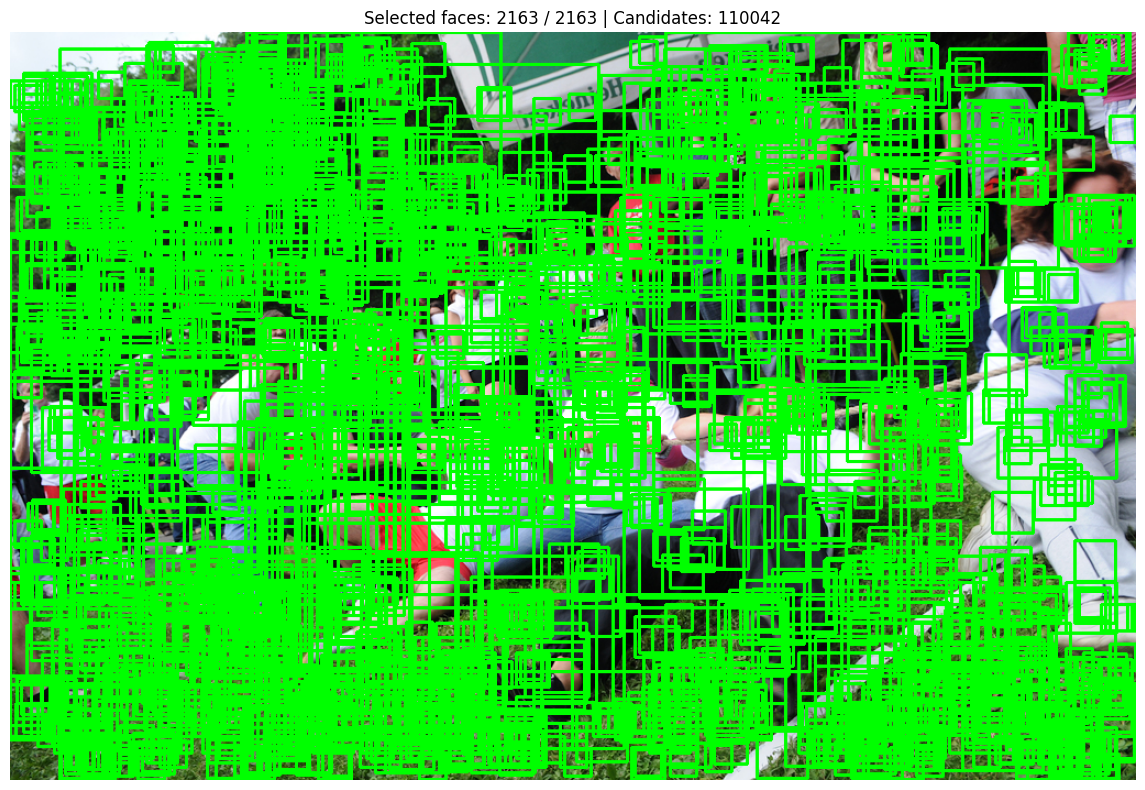

In [8]:
import matplotlib.pyplot as plt
import cv2

def plot_selected_face_squares(img_path, classifier, selected_indices=None, color=(0, 255, 0), thickness=2, figsize=(12, 8)):
    """
    Run detection on an image path and plot square boxes for selected detections.

    Args:
        img_path (str): Path to image.
        classifier: CascadeClassifier instance with predict_no_merge method.
        selected_indices (list[int] | int | None):
            - None -> plot all detections
            - int or list[int] -> plot only these detection indices
    """
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {img_path}")

    faces, candidates = classifier.predict_no_merge(
        img_path=img_path,
        return_candidate_count=True,
    )

    # Normalize index selection
    if selected_indices is None:
        selected_indices = list(range(len(faces)))
    elif isinstance(selected_indices, int):
        selected_indices = [selected_indices]

    valid_indices = [i for i in selected_indices if 0 <= i < len(faces)]
    selected_faces = [faces[i] for i in valid_indices]

    h_img, w_img = img.shape[:2]
    boxed = img.copy()

    for face in selected_faces:
        x, y, w, h = int(face['x']), int(face['y']), int(face['w']), int(face['h'])

        # Convert each detection to a square centered on the original box
        side = max(w, h)
        cx, cy = x + w // 2, y + h // 2
        x0 = max(0, cx - side // 2)
        y0 = max(0, cy - side // 2)
        x1 = min(w_img - 1, x0 + side)
        y1 = min(h_img - 1, y0 + side)

        cv2.rectangle(boxed, (x0, y0), (x1, y1), color, thickness)

    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(boxed, cv2.COLOR_BGR2RGB))
    plt.title(
        f"Selected faces: {len(selected_faces)} / {len(faces)} | Candidates: {candidates}"
    )
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return faces, selected_faces, boxed

# Example usage:
faces, selected_faces, boxed = plot_selected_face_squares(
    img_path=filepath,
    classifier=classifier,
    selected_indices=None,  # e.g. [0, 2, 5] to plot specific detections only
)

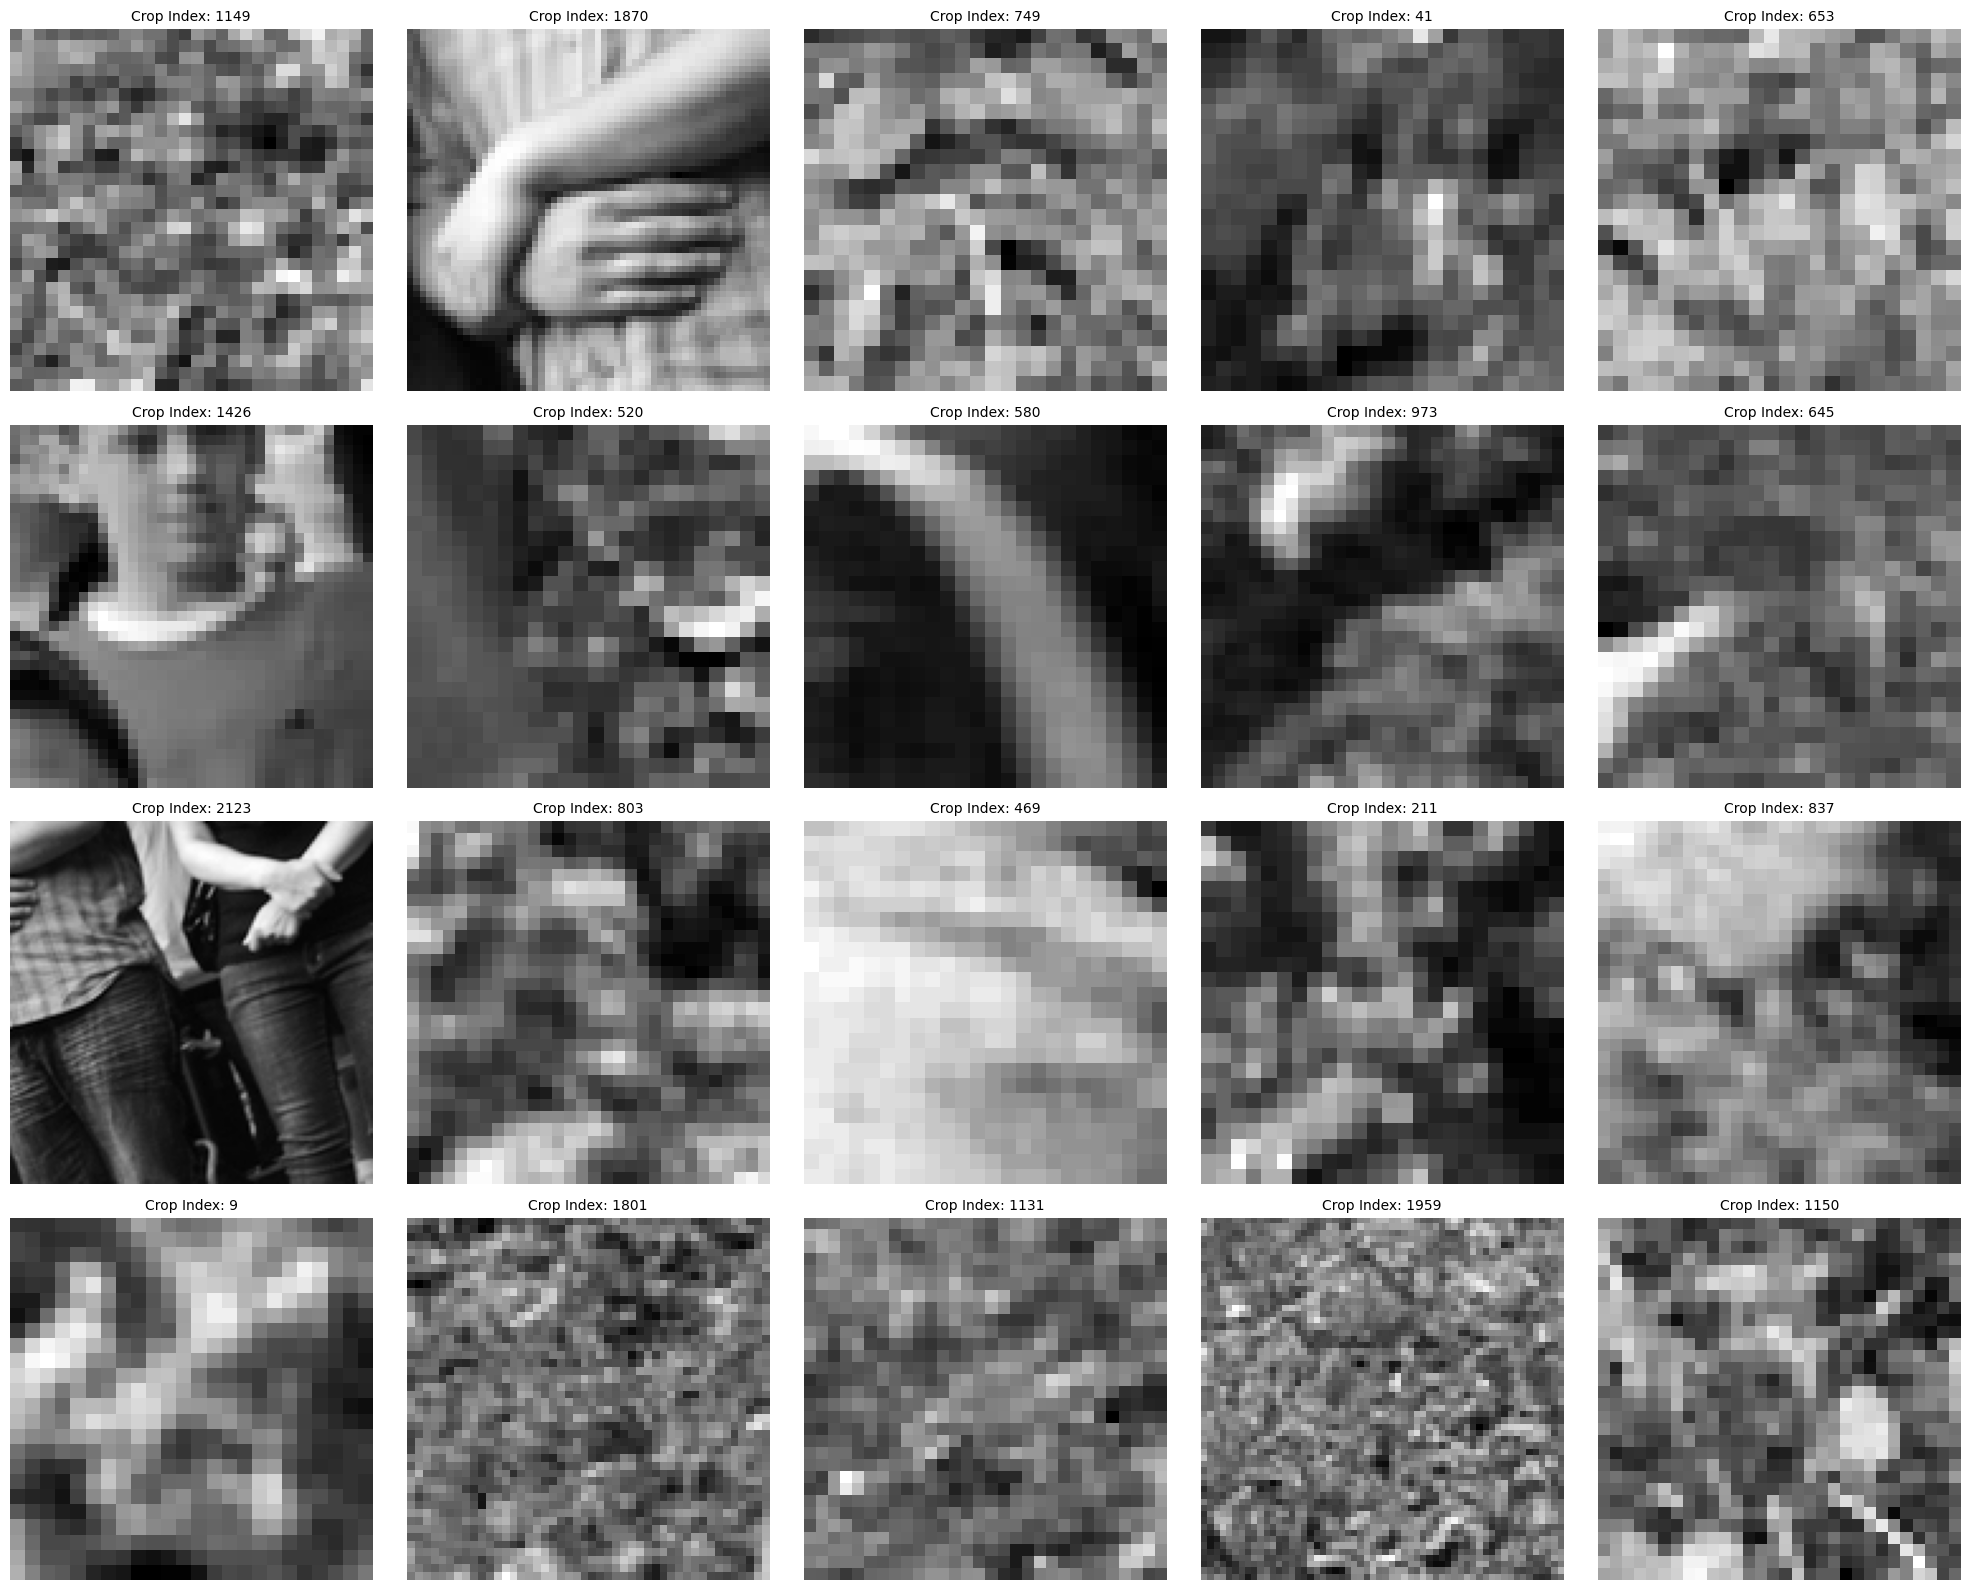

In [9]:
import numpy as np
import matplotlib.pyplot as plt


# rng = np.random.default_rng(CONFIG.seed)

# Get random indices instead of random crops
sample_indices = np.random.choice(len(crops), size=20, replace=False)
sample = [crops[i] for i in sample_indices]

def show_images(images, indices):
    fig, axes = plt.subplots(4, 5, figsize=(20, 16))
    for ax, img, crop_idx in zip(axes.flatten(), images, indices):
        ax.imshow(img, cmap='gray')
        ax.set_title(f'Crop Index: {crop_idx}', fontsize=10)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_images([i['img'] for i in sample], sample_indices)